In [7]:
import math
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import deque
from base64 import b64encode
from IPython.display import HTML

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [8]:
class RandomLaneEnvDQN:
    def __init__(self, target_lane='lower'):
        """
        Môi trường 2D tự động sinh đường cong ngẫu nhiên mỗi episode.
        target_lane: 'lower' (làn dưới) hoặc 'upper' (làn trên)
        """
        self.target_lane = target_lane
        self.road_height = 160
        self.y_base = 200
        self.X_goal = 940
        self.vehicle_height = 24

        # Biến hình học đường đua
        self.A = 50.0
        self.omega = 0.015
        self.phi = 0.0
        self.reset()

    def get_y_center(self, x):
        # Đường cong Sin với các tham số biến đổi ngẫu nhiên
        return self.y_base + self.A * math.sin(self.omega * x + self.phi)

    def get_target_y(self, x):
        y_top = self.get_y_center(x)
        if self.target_lane == 'lower':
            return y_top + (3 * self.road_height / 4)  # Tâm làn dưới (cách vạch đứt 20px)
        else:
            return y_top + (self.road_height / 4)      # Tâm làn trên

    def reset(self):
        self.x = 0.0

        # Mở rộng dải biến đổi để thấy rõ sự khác biệt của từng bản đồ
        self.A = random.uniform(15.0, 75.0)          # Biên độ sóng (độ nhô cao/thấp của khúc cua)
        self.omega = random.uniform(0.008, 0.035)    # Tần số (khúc cua thưa hoặc rất dốc/gắt)
        self.phi = random.uniform(0, 2 * math.pi)    # Điểm bắt đầu sóng (lên dốc hay xuống dốc ngay từ xuất phát)

        self.y_target = self.get_target_y(self.x)
        self.y = self.y_target

        d_t = self.y - self.y_target
        return np.array([d_t, self.x / 1000.0, self.A / 100.0, self.omega * 100], dtype=np.float32)

    def step(self, action):
        # Action space: 0: Up (-2px), 1: Hold (0px), 2: Down (+2px)
        dy = -2 if action == 0 else (0 if action == 1 else 2)

        self.x += 3.0
        self.y += dy

        y_top_edge = self.get_y_center(self.x)
        y_bottom_edge = y_top_edge + self.road_height
        self.y_target = self.get_target_y(self.x)

        d_t = self.y - self.y_target

        # Kiểm tra điều kiện va chạm và về đích
        crash = (self.y - self.vehicle_height / 2 < y_top_edge) or (self.y + self.vehicle_height / 2 > y_bottom_edge)
        reached_goal = self.x >= self.X_goal
        done = crash or reached_goal

        # Reward Shaping
        if crash:
            reward = -100.0
        elif reached_goal:
            reward = +200.0
        else:
            reward = 10.0 - abs(d_t) / 4.0 + 1.0

        next_state = np.array([d_t, self.x / 1000.0, self.A / 100.0, self.omega * 100], dtype=np.float32)
        return next_state, reward, done

In [9]:
class DQN(nn.Module):
    def __init__(self, state_dim=4, action_dim=3):
        super(DQN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.network(x)


class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(*random.sample(self.buffer, batch_size))
        return (np.array(state), np.array(action), np.array(reward, dtype=np.float32),
                np.array(next_state), np.array(done, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)

In [10]:
class DQNAgent:
    def __init__(self, state_dim=4, action_dim=3, lr=1e-3, gamma=0.99):
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.985

        self.policy_net = DQN(state_dim, action_dim).to(device)
        self.target_net = DQN(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(capacity=20000)

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.policy_net(state_t)
        return torch.argmax(q_values).item()

    def train_step(self, batch_size=64):
        if len(self.memory) < batch_size:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(batch_size)

        states_t = torch.FloatTensor(states).to(device)
        actions_t = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards_t = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        next_states_t = torch.FloatTensor(next_states).to(device)
        dones_t = torch.FloatTensor(dones).unsqueeze(1).to(device)

        q_values = self.policy_net(states_t).gather(1, actions_t)

        with torch.no_grad():
            max_next_q = self.target_net(next_states_t).max(1)[0].unsqueeze(1)
            target_q = rewards_t + (1 - dones_t) * self.gamma * max_next_q

        loss = nn.MSELoss()(q_values, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

=== BẮT ĐẦU HUẤN LUYỆN DQN TRÊN MÔI TRƯỜNG SINH NGẪU NHIÊN ===
Episode   1/300 | Reward:  -459.3 | Epsilon: 0.985
Episode  25/300 | Reward:   213.0 | Epsilon: 0.685
Episode  50/300 | Reward:  3215.7 | Epsilon: 0.470
Episode  75/300 | Reward:  2740.0 | Epsilon: 0.322
Episode 100/300 | Reward:   636.4 | Epsilon: 0.221
Episode 125/300 | Reward:   383.1 | Epsilon: 0.151
Episode 150/300 | Reward:    37.1 | Epsilon: 0.104
Episode 175/300 | Reward:   377.4 | Epsilon: 0.071
Episode 200/300 | Reward:  2981.3 | Epsilon: 0.049
Episode 225/300 | Reward:   109.6 | Epsilon: 0.033
Episode 250/300 | Reward:  3236.8 | Epsilon: 0.023
Episode 275/300 | Reward:  3294.2 | Epsilon: 0.016
Episode 300/300 | Reward:  3531.0 | Epsilon: 0.011


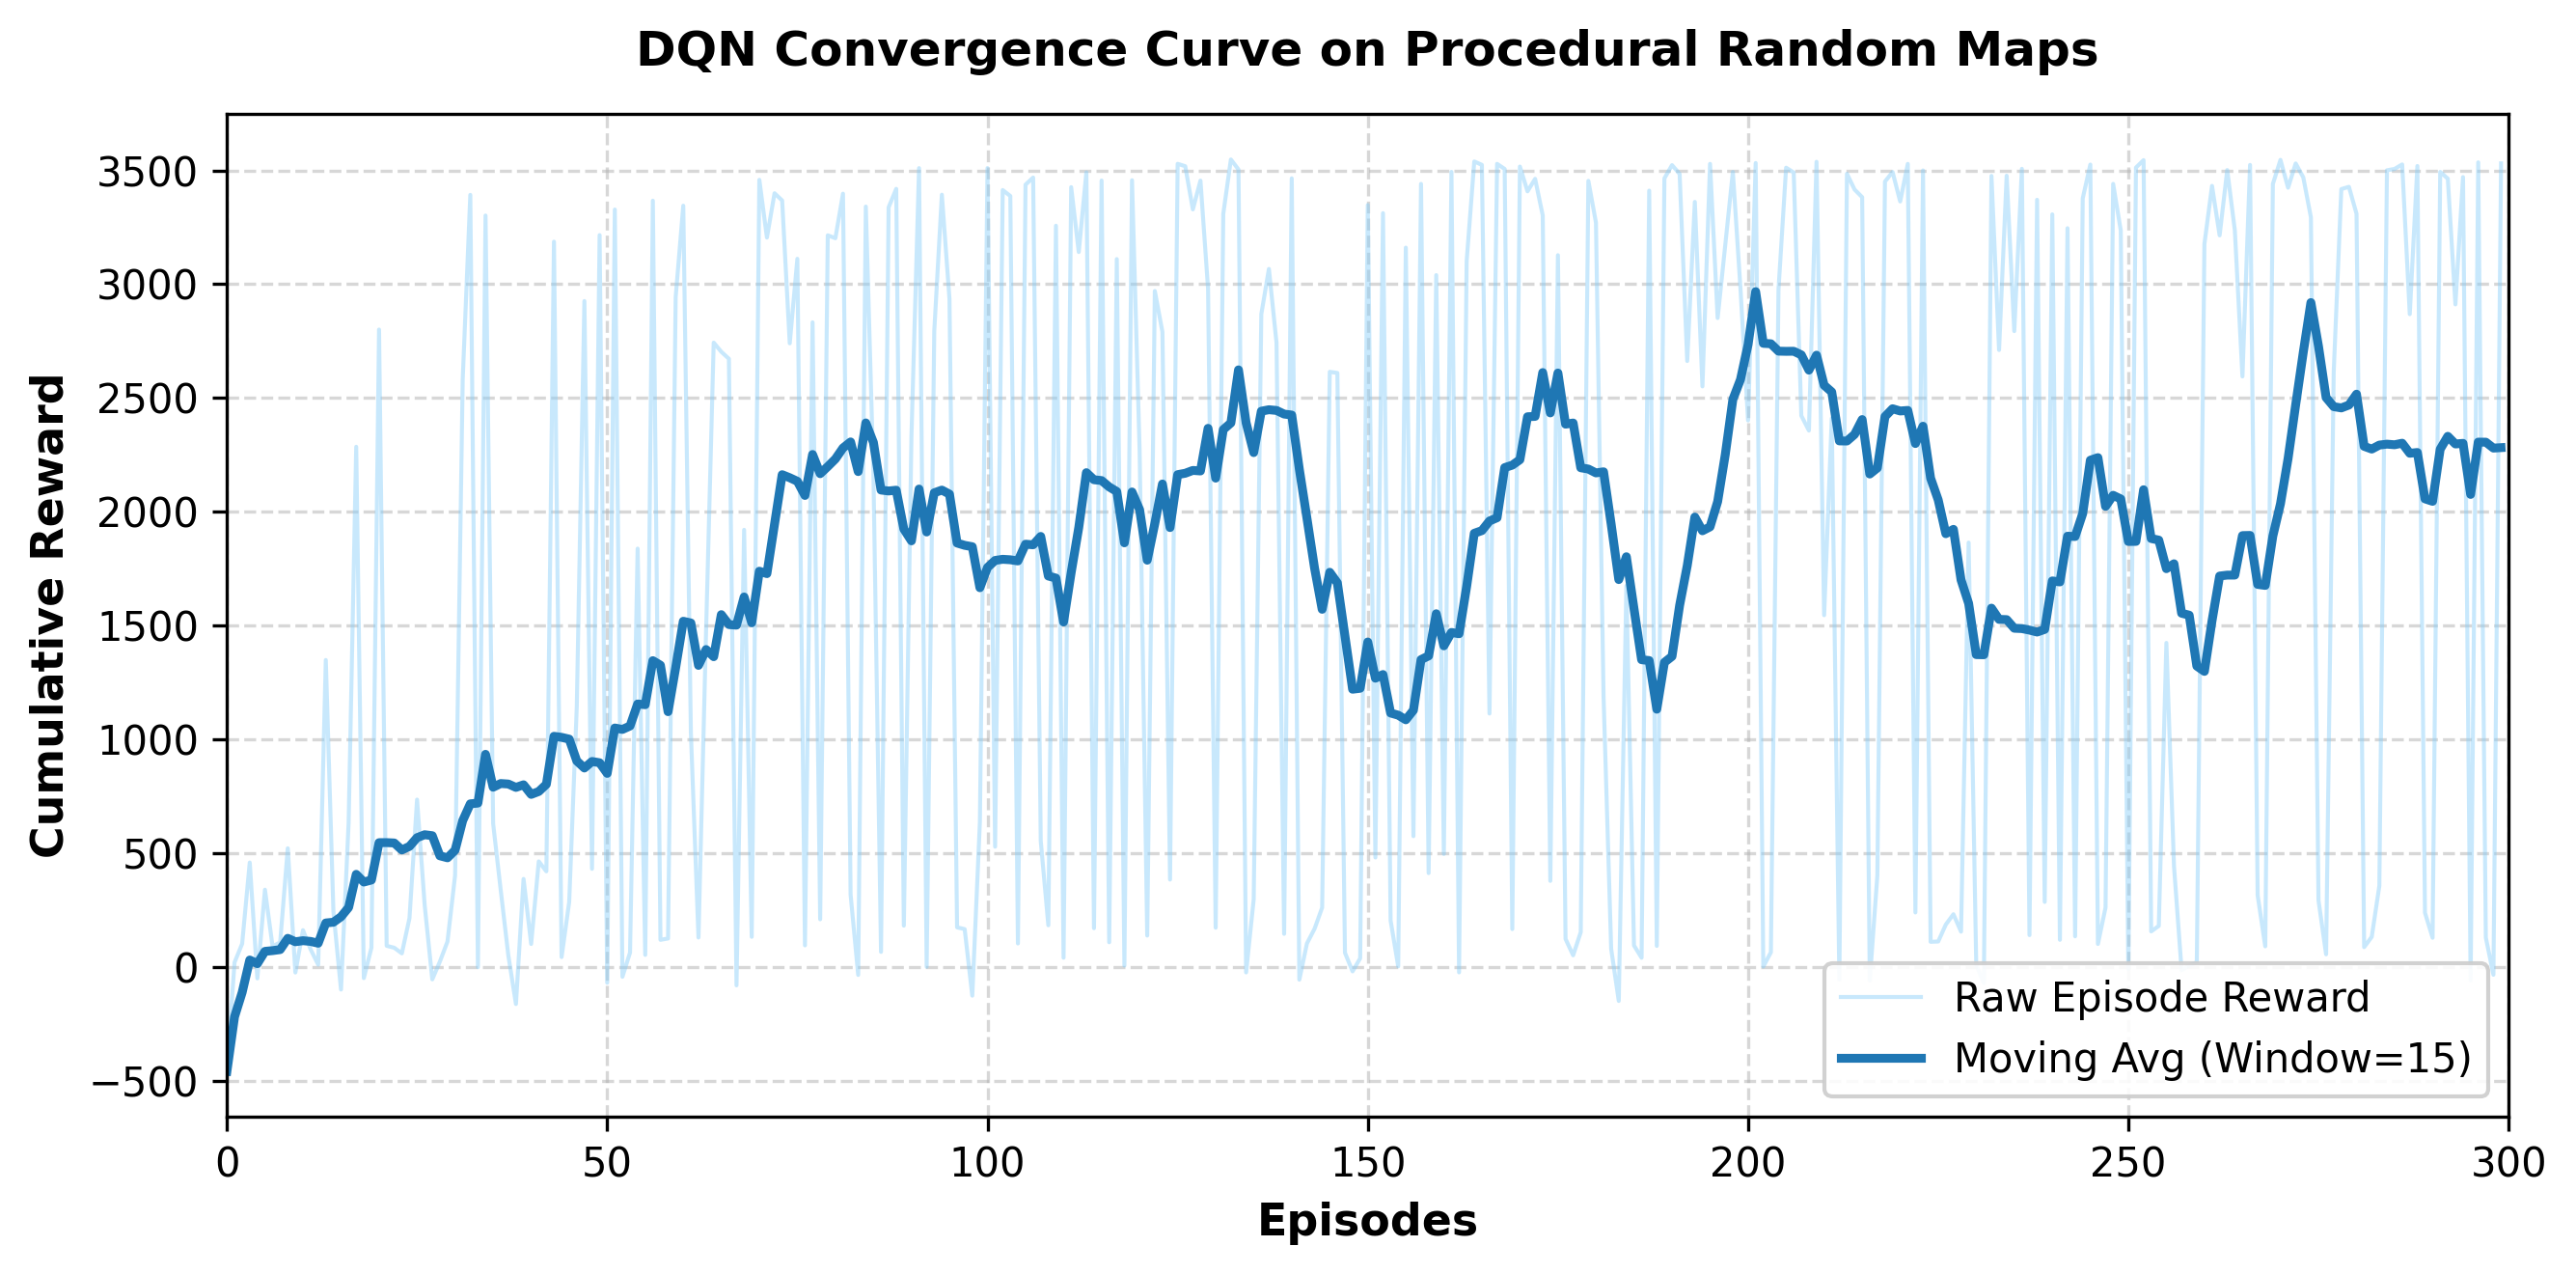

In [14]:
def plot_smoothed_rewards(rewards_history, window_size=15):
    rewards_arr = np.array(rewards_history)

    # Tính đường trung bình trượt
    smoothed_rewards = np.zeros_like(rewards_arr, dtype=np.float64)
    for i in range(len(rewards_arr)):
        start_idx = max(0, i - window_size + 1)
        smoothed_rewards[i] = np.mean(rewards_arr[start_idx:i + 1])

    plt.figure(figsize=(9, 4.5), dpi=300)

    # 1. Vẽ dữ liệu thô dạng đường mờ phía sau
    plt.plot(rewards_arr, color='#87cefa', alpha=0.45, linewidth=1.0, label='Raw Episode Reward')

    # 2. Vẽ đường trung bình trượt mượt mà phía trước
    plt.plot(smoothed_rewards, color='#1f77b4', linewidth=2.2, label=f'Moving Avg (Window={window_size})')

    # 3. Định dạng đồ thị chuyên nghiệp
    plt.title('DQN Convergence Curve on Procedural Random Maps', fontsize=12, fontweight='bold', pad=12)
    plt.xlabel('Episodes', fontsize=11, fontweight='bold')
    plt.ylabel('Cumulative Reward', fontsize=11, fontweight='bold')

    plt.xlim(0, len(rewards_history))
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right', frameon=True, framealpha=0.9, fontsize=10)
    plt.tight_layout()

    # Lưu ảnh nét cao vào máy/Colab để chèn vào báo cáo
    plt.savefig("dqn_learning_curve_clean.png", dpi=300)
    plt.show()


def train_procedural_dqn(episodes=300, batch_size=64):
    env = RandomLaneEnvDQN(target_lane='lower')
    agent = DQNAgent(state_dim=4, action_dim=3)
    rewards_history = []

    print("=== BẮT ĐẦU HUẤN LUYỆN DQN TRÊN MÔI TRƯỜNG SINH NGẪU NHIÊN ===")
    for ep in range(1, episodes + 1):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, done = env.step(action)
            agent.memory.push(state, action, reward, next_state, done)

            agent.train_step(batch_size)
            state = next_state
            total_reward += reward

        if ep % 5 == 0:
            agent.update_target_network()

        agent.decay_epsilon()
        rewards_history.append(total_reward)

        if ep % 25 == 0 or ep == 1:
            print(f"Episode {ep:3d}/{episodes} | Reward: {total_reward:7.1f} | Epsilon: {agent.epsilon:.3f}")

    # Gọi hàm vẽ đồ thị đã được làm mượt
    plot_smoothed_rewards(rewards_history, window_size=15)

    return agent, env

# Thực thi huấn luyện
agent, trained_env = train_procedural_dqn(episodes=300)

In [15]:
def generate_and_display_random_video(agent, video_filename="dqn_procedural_result.mp4"):
    # Tạo môi trường mới tinh với đường cong sinh ngẫu nhiên mới
    env = RandomLaneEnvDQN(target_lane='lower')
    state = env.reset()
    done = False

    fps = 30
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(video_filename, fourcc, fps, (1000, 400))
    agent.epsilon = 0.0  # Tắt khám phá để kiểm tra chính sách tốt nhất

    while not done:
        frame = np.ones((400, 1000, 3), dtype=np.uint8) * 255

        # 1. Vẽ Cỏ và Mặt đường
        for x in range(0, 1000, 2):
            y_c = int(env.get_y_center(x))
            cv2.line(frame, (x, 0), (x, y_c), (34, 139, 34), 2)
            cv2.line(frame, (x, y_c + 160), (x, 400), (34, 139, 34), 2)
            cv2.line(frame, (x, y_c), (x, y_c + 160), (50, 50, 50), 2)

        # 2. Vẽ Vạch đứt phân làn ở giữa mặt đường
        for x in range(0, 1000, 20):
            y_c = int(env.get_y_center(x))
            y_middle = y_c + 80
            cv2.line(frame, (x, y_middle), (min(x + 10, 1000), y_middle), (255, 255, 255), 2)

        # 3. Vẽ Vạch đích
        cv2.line(frame, (env.X_goal, 0), (env.X_goal, 400), (255, 0, 0), 3)

        # 4. Vẽ Xe (Xe chạy lọt lòng làn dưới)
        vx, vy = int(env.x), int(env.y)
        vh, vw = env.vehicle_height, 30
        cv2.rectangle(frame, (vx - vw//2, vy - vh//2), (vx + vw//2, vy + vh//2), (0, 0, 255), -1)

        out.write(frame)

        action = agent.select_action(state)
        next_state, reward, done = env.step(action)
        state = next_state

    out.release()
    print(f"--> Đã lưu video thành công: {video_filename}")

    # Hiển thị trực tiếp trong Notebook
    mp4 = open(video_filename, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML(f"""
    <video width="750" controls autoplay loop>
          <source src="{data_url}" type="video/mp4">
    </video>
    """)

# Chạy và xem Video kết quả
generate_and_display_random_video(agent)

--> Đã lưu video thành công: dqn_procedural_result.mp4
